# Assignment 6: Data Analytics 3

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
col_names = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species']

df = pd.read_csv(url, names=col_names)

print(df)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width         Species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  150 non-null    float64
 1   Sepal_Width   150 non-null    float64
 2   Petal_Length  150 non-null    float64
 3   Petal_Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
print(df.describe())

       Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [5]:
print(df.isnull().sum())

Sepal_Length    0
Sepal_Width     0
Petal_Length    0
Petal_Width     0
Species         0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

print("\nEncoded Data:")
print(df.head())


Encoded Data:
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width  Species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [7]:
X = df[['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width']]
y = df['Species']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (120, 4)
Test shape: (30, 4)


In [9]:
model = GaussianNB()
model.fit(X_train, y_train)

print("\nModel trained successfully")


Model trained successfully


In [10]:
y_pred = model.predict(X_test)

print("\nPredicted values:")
print(y_pred)


Predicted values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [11]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
accuracy = np.sum(y_pred == y_test) / len(y_test)
print("\nAccuracy:", accuracy)


Accuracy: 1.0


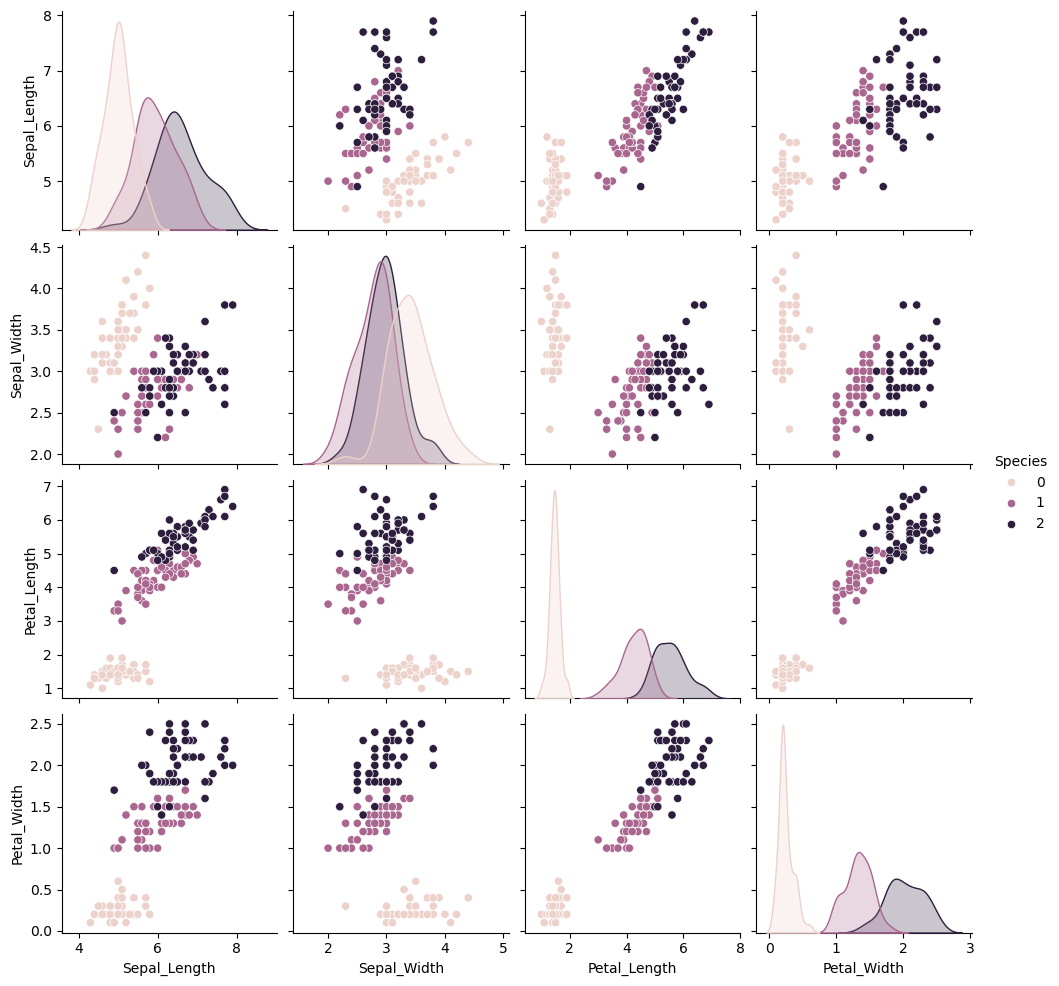

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='Species')
plt.show()

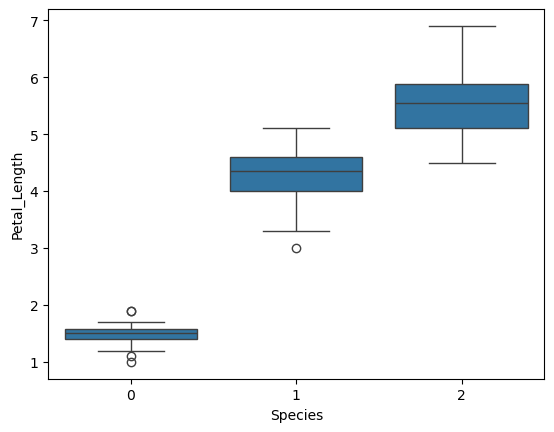

In [14]:
sns.boxplot(x='Species', y='Petal_Length', data=df)
plt.show()

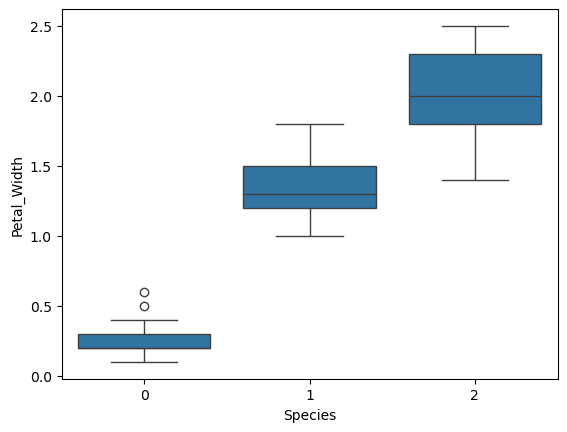

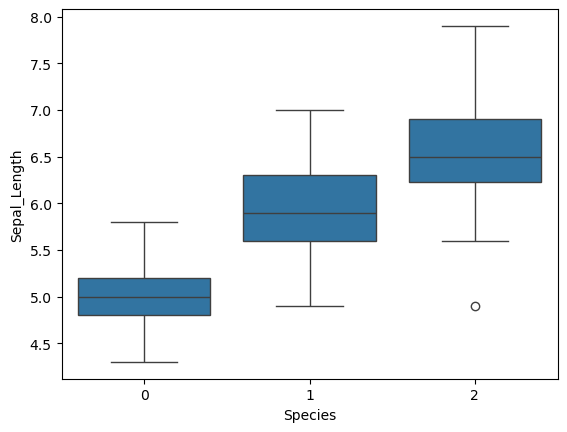

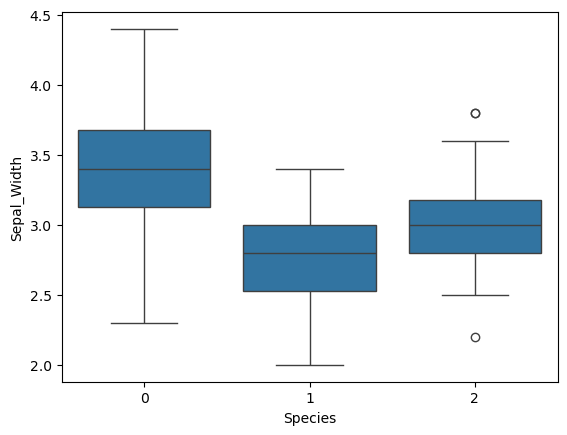

In [15]:
sns.boxplot(x='Species', y='Petal_Width', data=df)
plt.show()
sns.boxplot(x='Species', y='Sepal_Length', data=df)
plt.show()
sns.boxplot(x='Species', y='Sepal_Width', data=df)
plt.show()

In [16]:
df.corr()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
Sepal_Length,1.000000,-0.109369,0.871754,0.817954,0.782561
Sepal_Width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
Petal_Length,0.871754,-0.420516,1.000000,0.962757,0.949043
Petal_Width,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.782561,-0.419446,0.949043,0.956464,1.000000


In [17]:
result = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
result.to_csv("naive_bayes_results.csv", index=False)

print("\nResults saved successfully!")


Results saved successfully!
